# Block Bootstrapping: Stress Testing Your Strategy the Right Way

**Cordell Tanny, CFA, FRM, FDP**  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny/](https://github.com/ctanny/quant-finance-snippets)

---

In the previous two notebooks we proved that asset returns are not normally distributed and identified the Johnson SU distribution as the best fit across six major asset classes. But even a well-fitted parametric distribution misses something important: the structure that exists within return series over time.

Financial returns are not independent draws from a distribution. Volatility clusters. Trends persist. Assets that are uncorrelated in calm markets move together in a crisis. When you shuffle returns randomly to run a simulation, you destroy all of that structure and produce a sanitized version of reality that your actual strategy will never experience.

Block bootstrapping solves this by resampling entire consecutive chunks of history rather than individual days. The structure within each block is preserved because you are lifting real sequences of returns from the actual data.

In this notebook we will:
1. Show why independent resampling destroys the autocorrelation structure of returns
2. Explain block bootstrapping and how block length affects the results
3. Show how block length changes the shape of the simulated return distribution
4. Demonstrate that block bootstrapping preserves cross-asset correlations while independent resampling does not
5. Apply block bootstrapping to stress test a simple moving average crossover strategy on SPY


## 1. Imports and Setup

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

np.random.seed(42)

# ── Parameters ─────────────────────────────────────────────────────────────
# Centralized here so you can re-run with different settings in one edit
START_DATE    = '2010-01-01'
N_SIMULATIONS = 1000       # number of bootstrap simulations
BLOCK_LENGTHS = [5, 21, 63] # short (1wk), medium (1mo), long (1qtr)
MA_SHORT      = 50          # moving average crossover: short window
MA_LONG       = 200         # moving average crossover: long window

# Same ETF universe as the previous notebooks
tickers = {
    'SPY':  'US Equity',
    'TLT':  'Long Bonds',
    'GLD':  'Gold',
    'QQQ':  'Tech / Growth',
    'JNK':  'High Yield Bonds',
    'IBND': 'International Bonds',
}

## 2. Download Return Data

In [2]:
raw = yf.download(
    list(tickers.keys()),
    start=START_DATE,
    auto_adjust=True,
    progress=False
)['Close']

returns = np.log(raw / raw.shift(1)).dropna()

# SPY returns for the strategy section
spy_returns = returns['SPY']
spy_prices  = raw['SPY'].dropna()

print(f"Period       : {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Observations : {len(returns)} trading days")

Period       : 2010-05-21 to 2026-05-15
Observations : 4021 trading days


## 3. Why Independent Resampling Fails

The simplest way to simulate return paths is to shuffle the historical returns randomly and replay them. This preserves the marginal distribution of returns — the mean, standard deviation, skewness, and kurtosis all remain intact. But it destroys the time series structure.

**Autocorrelation** measures how much today's return is related to yesterday's, or last week's. In real financial data, while return autocorrelation is low, volatility autocorrelation is high — calm periods tend to be followed by calm periods, and volatile periods by volatile periods. This is the well-known volatility clustering effect.

When you shuffle returns independently, you break these dependencies. A -8% day might now be followed by a +6% day followed by a +0.1% day. In reality, an -8% day almost always occurs in a cluster of other large moves.

The chart below shows the autocorrelation of squared returns (a proxy for volatility) for actual SPY returns versus independently resampled returns. Squared return autocorrelation is the standard way to detect volatility clustering.

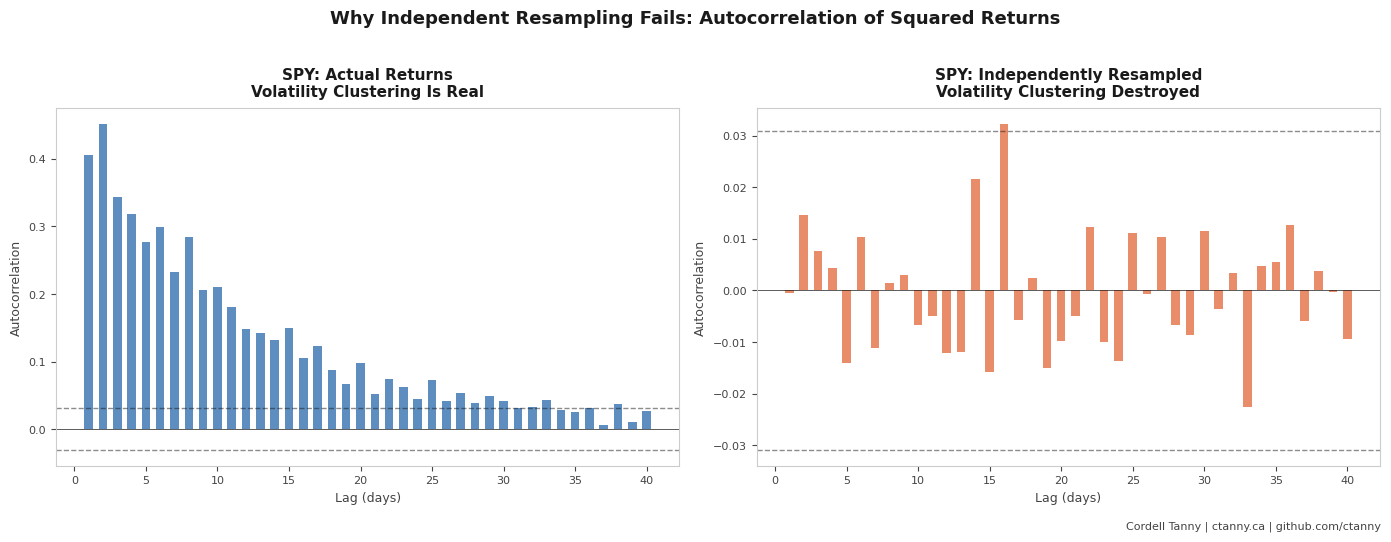

In [3]:
def plot_autocorrelation(series, ax, title, color, max_lags=40):
    """
    Plot autocorrelation of squared returns up to max_lags.
    Squared returns are a standard proxy for volatility.
    The 95% confidence band is shown in gray -- bars outside it
    indicate statistically significant autocorrelation.
    """
    sq = series ** 2
    acf_vals = [sq.autocorr(lag=i) for i in range(1, max_lags + 1)]
    conf      = 1.96 / np.sqrt(len(series))  # 95% confidence interval

    ax.bar(range(1, max_lags + 1), acf_vals, color=color, alpha=0.7, width=0.6)
    ax.axhline(conf,  color='#1a1a1a', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(-conf, color='#1a1a1a', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(0,     color='#1a1a1a', linewidth=0.5)
    ax.set_title(title, color='#1a1a1a', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Lag (days)', color='#444444', fontsize=9)
    ax.set_ylabel('Autocorrelation', color='#444444', fontsize=9)
    ax.tick_params(colors='#444444', labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#cccccc')


# Independently resampled returns: same values, random order
spy_shuffled = pd.Series(
    np.random.choice(spy_returns.values, size=len(spy_returns), replace=False),
    index=spy_returns.index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

plot_autocorrelation(spy_returns,  axes[0],
                     'SPY: Actual Returns\nVolatility Clustering Is Real',
                     '#185FA5')
plot_autocorrelation(spy_shuffled, axes[1],
                     'SPY: Independently Resampled\nVolatility Clustering Destroyed',
                     '#E05C2A')

fig.suptitle('Why Independent Resampling Fails: Autocorrelation of Squared Returns',
             color='#1a1a1a', fontsize=13, fontweight='bold', y=1.02)
plt.figtext(0.99, -0.02,
            'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('autocorrelation_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

## 4. Block Bootstrapping: The Concept

Block bootstrapping preserves the time series structure by resampling consecutive blocks of returns rather than individual observations.

The algorithm is straightforward:
1. Choose a block length (for example, 21 trading days)
2. Randomly select a starting point in the return series
3. Take the next 21 consecutive returns as a block
4. Repeat until you have enough blocks to fill the desired simulation length
5. Concatenate the blocks into a simulated return path

Because each block is a real sequence of consecutive returns, the within-block structure — volatility clustering, momentum, mean reversion — is preserved. What you lose is the structure across block boundaries, which is an acceptable tradeoff.

**The block length tradeoff:**

| Block length | Preserves | Loses |
|---|---|---|
| Short (5 days) | Short-term autocorrelation | Longer regime structure |
| Medium (21 days) | Monthly patterns, vol clustering | Multi-month trends |
| Long (63 days) | Quarterly regimes | More variability in output |

There is no universally correct block length. The right choice depends on the structure you are trying to preserve, which is why we compare all three below.

In [4]:
def block_bootstrap(returns, block_length, n_simulations):
    """
    Generate simulated return paths using block bootstrapping.

    Parameters
    ----------
    returns      : array-like, historical return series
    block_length : int, number of consecutive returns per block
    n_simulations: int, number of simulated paths to generate

    Returns
    -------
    np.ndarray of shape (n_simulations, len(returns))
    Each row is one simulated return path of the same length
    as the original series.
    """
    r      = np.array(returns)
    n      = len(r)
    paths  = []

    for _ in range(n_simulations):
        simulated = []

        while len(simulated) < n:
            # Pick a random starting point for the block
            # Ensure the block fits within the series
            start = np.random.randint(0, n - block_length + 1)
            block = r[start: start + block_length]
            simulated.extend(block)

        # Trim to exact length
        paths.append(simulated[:n])

    return np.array(paths)

## 5. How Block Length Affects the Simulated Distribution

We run block bootstrapping on SPY across three block lengths and compare the resulting distributions to the original return data.

What to look for:
- How closely does each block length replicate the shape of the original distribution?
- Does a longer block length produce heavier or lighter tails?
- Which block length best preserves the fat tail behavior we identified in notebook one?

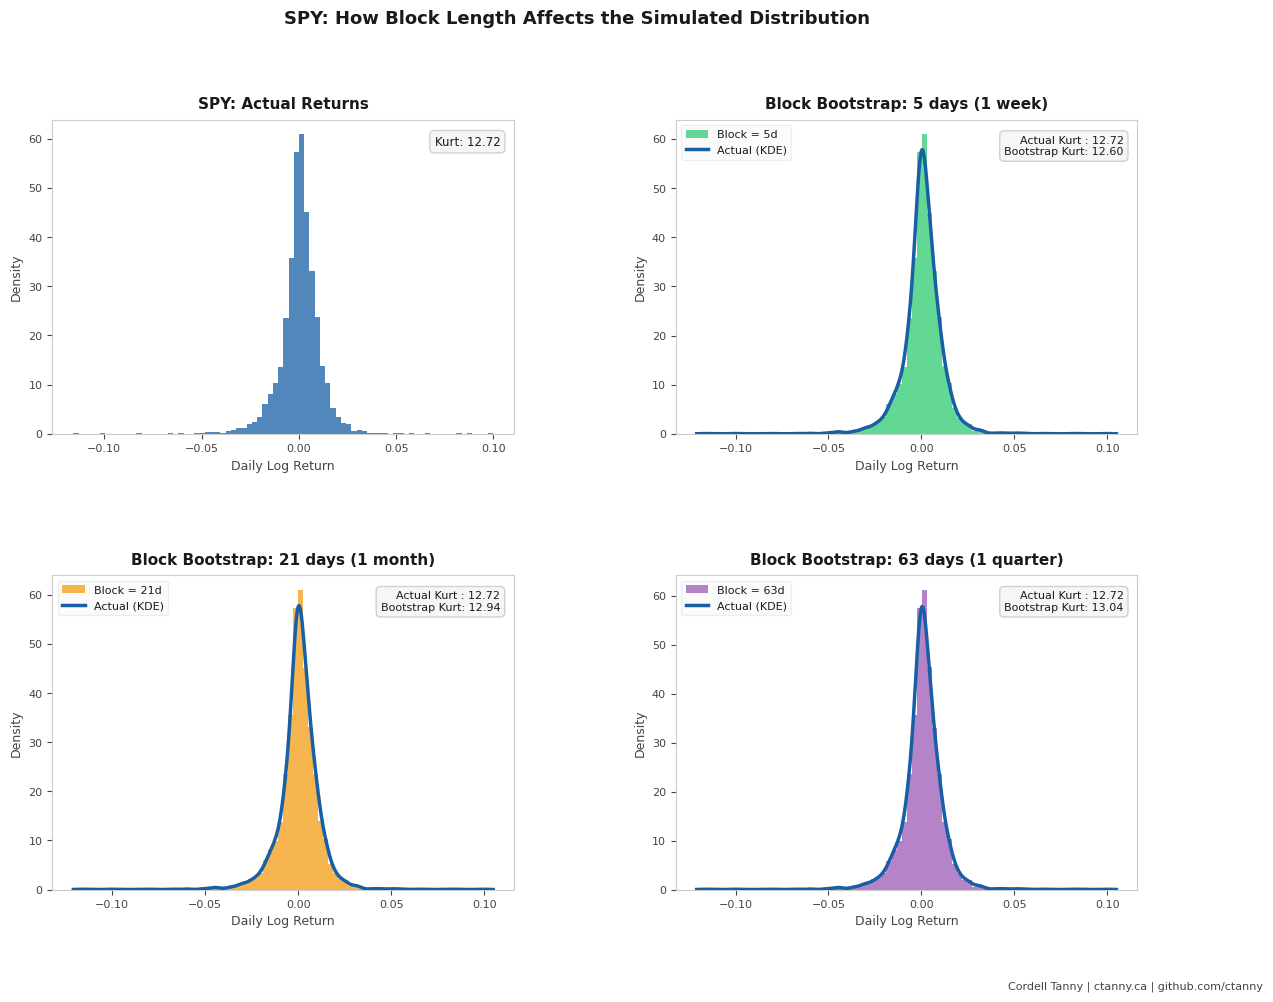

In [5]:
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

colors = ['#2ECC71', '#F39C12', '#9B59B6']
r      = spy_returns.values

# KDE of actual returns -- computed once, reused in every panel
kde_actual = stats.gaussian_kde(r, bw_method='scott')
x_range    = np.linspace(r.min() - 0.005, r.max() + 0.005, 500)
kde_vals   = kde_actual(x_range)

# Original distribution (top left) -- histogram only
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor('white')
ax0.hist(r, bins=80, density=True, color='#185FA5', alpha=0.75, label='Actual')
ax0.set_title('SPY: Actual Returns', color='#1a1a1a', fontsize=11,
              fontweight='bold', pad=8)
ax0.set_xlabel('Daily Log Return', color='#444444', fontsize=9)
ax0.set_ylabel('Density', color='#444444', fontsize=9)
ax0.tick_params(colors='#444444', labelsize=8)
for sp in ax0.spines.values():
    sp.set_edgecolor('#cccccc')
ax0.text(0.97, 0.95, f'Kurt: {stats.kurtosis(r):.2f}',
         transform=ax0.transAxes, color='#1a1a1a', fontsize=8.5,
         ha='right', va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5',
                   edgecolor='#cccccc', alpha=0.9))

# One panel per block length
positions = [gs[0, 1], gs[1, 0], gs[1, 1]]
labels    = ['5 days (1 week)', '21 days (1 month)', '63 days (1 quarter)']

for idx, (bl, color, pos, label) in enumerate(
        zip(BLOCK_LENGTHS, colors, positions, labels)):

    simulated = block_bootstrap(spy_returns, bl, N_SIMULATIONS)
    all_sim   = simulated.flatten()

    ax = fig.add_subplot(pos)
    ax.set_facecolor('white')

    # Bootstrapped distribution as histogram
    ax.hist(all_sim, bins=80, density=True, color=color,
            alpha=0.75, label=f'Block = {bl}d', zorder=2)

    # Actual returns as a smooth KDE curve -- always visible on top
    ax.plot(x_range, kde_vals, color='#185FA5', linewidth=2.5,
            label='Actual (KDE)', zorder=3)

    ax.set_title(f'Block Bootstrap: {label}',
                 color='#1a1a1a', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Daily Log Return', color='#444444', fontsize=9)
    ax.set_ylabel('Density',          color='#444444', fontsize=9)
    ax.tick_params(colors='#444444',  labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#cccccc')

    ax.text(0.97, 0.95,
            f'Actual Kurt : {stats.kurtosis(r):.2f}\n'
            f'Bootstrap Kurt: {stats.kurtosis(all_sim):.2f}',
            transform=ax.transAxes, color='#1a1a1a', fontsize=8,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5',
                      edgecolor='#cccccc', alpha=0.9))
    ax.legend(fontsize=8, framealpha=0.3, labelcolor='#1a1a1a',
              facecolor='#f5f5f5', edgecolor='#cccccc')

fig.suptitle('SPY: How Block Length Affects the Simulated Distribution',
             color='#1a1a1a', fontsize=13, fontweight='bold', y=0.99)
plt.figtext(0.99, 0.01,
            'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.savefig('block_length_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

## 6. Preserving Cross-Asset Correlations

One of the most important properties of block bootstrapping for portfolio analysis is that it preserves cross-asset correlations. When markets sell off, correlations spike. Assets that diversify a portfolio in normal conditions often move together in a crisis. Independent resampling destroys this relationship because it shuffles each asset's returns separately.

Block bootstrapping applies the same block selections to all assets simultaneously, so the co-movement structure within each block is preserved.

The two heatmaps below compare the realized correlation matrix of our six ETFs against the correlation matrix produced by independent resampling. The block bootstrap correlation matrix (using a 21-day block) is shown alongside for comparison.

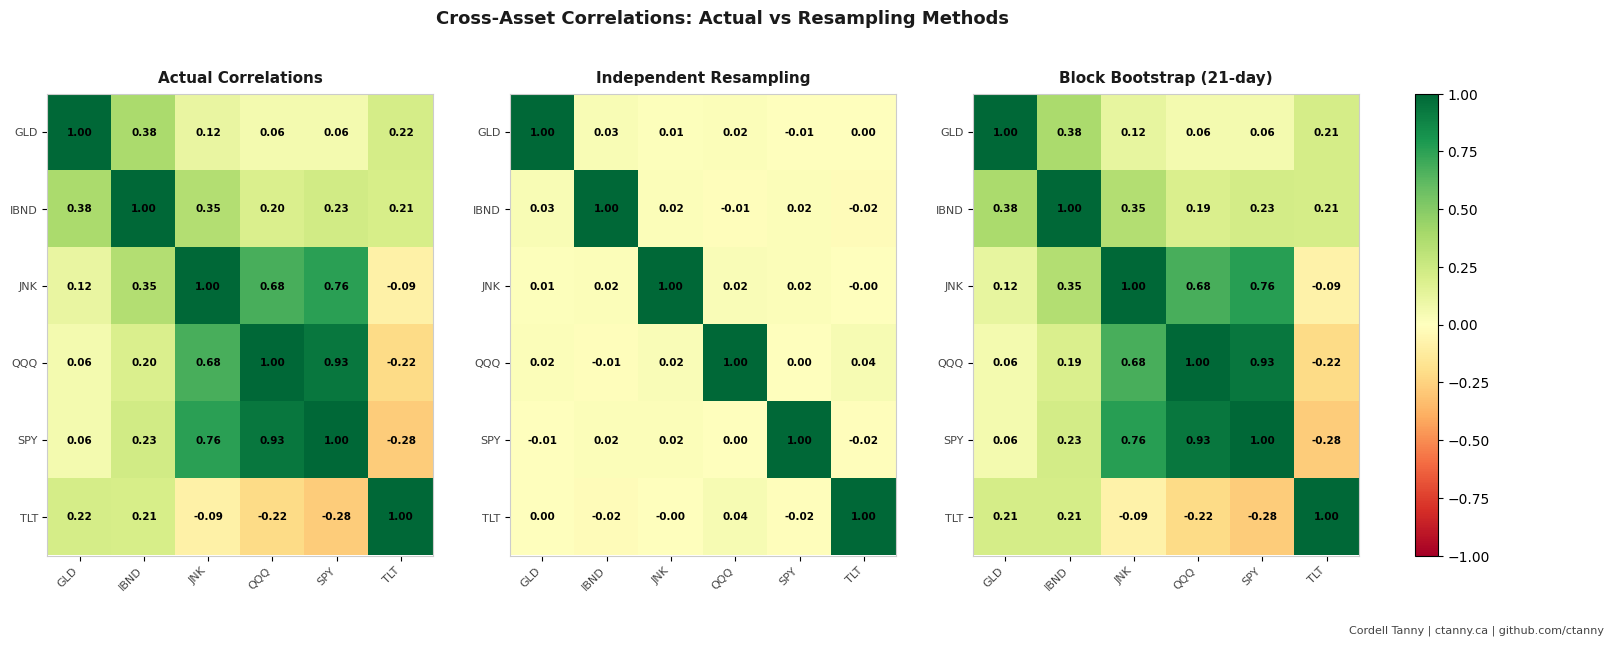

In [6]:
def block_bootstrap_multivariate(returns_df, block_length, n_simulations):
    """
    Block bootstrap for multiple assets simultaneously.
    The same block indices are applied to all assets to preserve
    cross-asset correlation structure.

    Parameters
    ----------
    returns_df   : pd.DataFrame, one column per asset
    block_length : int
    n_simulations: int

    Returns
    -------
    np.ndarray of shape (n_simulations, len(returns_df), n_assets)
    """
    r      = returns_df.values
    n, k   = r.shape
    paths  = []

    for _ in range(n_simulations):
        simulated = []
        while len(simulated) < n:
            start = np.random.randint(0, n - block_length + 1)
            # Same block applied to ALL assets simultaneously
            block = r[start: start + block_length, :]
            simulated.append(block)
        simulated = np.vstack(simulated)[:n, :]
        paths.append(simulated)

    return np.array(paths)


def plot_correlation_heatmap(corr_matrix, ax, title, vmin=-1, vmax=1):
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=vmin, vmax=vmax,
                   aspect='auto')
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right',
                       color='#444444', fontsize=8)
    ax.set_yticklabels(corr_matrix.index, color='#444444', fontsize=8)
    ax.set_title(title, color='#1a1a1a', fontsize=11, fontweight='bold', pad=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#cccccc')

    # Annotate cells with values
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix.columns)):
            ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                    ha='center', va='center',
                    color='black', fontsize=7.5, fontweight='bold')
    return im


# Realized correlation matrix
corr_actual = returns.corr()

# Independent resampling: shuffle each asset separately
shuffled_df = returns.apply(lambda col: np.random.permutation(col))
corr_shuffled = pd.DataFrame(
    shuffled_df, columns=returns.columns).corr()

# Block bootstrap correlation (21-day block, average across simulations)
bb_paths     = block_bootstrap_multivariate(returns, 21, 200)
corr_bb_list = [pd.DataFrame(p, columns=returns.columns).corr().values
                for p in bb_paths]
corr_bb      = pd.DataFrame(
    np.mean(corr_bb_list, axis=0), columns=returns.columns,
    index=returns.columns)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

plot_correlation_heatmap(corr_actual,   axes[0], 'Actual Correlations')
plot_correlation_heatmap(corr_shuffled, axes[1], 'Independent Resampling')
im = plot_correlation_heatmap(corr_bb,  axes[2], 'Block Bootstrap (21-day)')

fig.colorbar(im, ax=axes, orientation='vertical',
             fraction=0.02, pad=0.04)
fig.suptitle('Cross-Asset Correlations: Actual vs Resampling Methods',
             color='#1a1a1a', fontsize=13, fontweight='bold', y=1.02)
plt.figtext(0.99, -0.02,
            'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.savefig('correlation_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

## 7. Applying Block Bootstrap to a Strategy

The real test of any resampling method is whether it changes your view of a strategy's performance. A single backtest gives you one path through history. Block bootstrapping gives you thousands of alternative histories drawn from the same data, with the same structural properties.

We use a simple moving average crossover strategy on SPY:
- **Long signal**: 50-day moving average crosses above the 200-day moving average (the golden cross)
- **Flat signal**: 50-day crosses below the 200-day (exit to cash)
- No short selling, no leverage, no transaction costs

This is a well-known strategy that everyone recognizes, which makes it ideal for demonstrating the bootstrap concept without the strategy mechanics becoming a distraction.

The question we are asking is: does the strategy's edge survive when we stress test it across 1,000 alternative histories?

> **Important note on look-ahead bias**: The moving average signals are calculated on the simulated price paths reconstructed from the bootstrapped returns, not on the original price series. Each simulated path represents a plausible alternative history for SPY.

In [7]:
def ma_crossover_returns(price_series, short_window, long_window):
    """
    Simple moving average crossover strategy.
    Long when short MA > long MA, flat (in cash) otherwise.
    Signal is lagged by 1 day to avoid look-ahead bias:
    we can only act on yesterday's signal.

    Parameters
    ----------
    price_series : array-like, price series (not returns)
    short_window : int
    long_window  : int

    Returns
    -------
    strategy_returns : pd.Series
    """
    prices = pd.Series(price_series)
    ma_s   = prices.rolling(short_window).mean()
    ma_l   = prices.rolling(long_window).mean()

    # Signal: 1 = long, 0 = flat
    # Shift by 1 to avoid look-ahead bias
    signal = (ma_s > ma_l).astype(int).shift(1)

    # Daily log returns of the underlying
    daily_returns = np.log(prices / prices.shift(1))

    # Strategy return = signal * underlying return
    return (signal * daily_returns).dropna()


def total_return(return_series):
    """Convert a log return series to total cumulative return."""
    return np.exp(return_series.sum()) - 1


def sharpe_ratio(return_series, trading_days=252):
    """Annualized Sharpe ratio assuming zero risk-free rate."""
    if return_series.std() == 0:
        return 0
    return (return_series.mean() / return_series.std()) * np.sqrt(trading_days)


# ── Actual strategy performance ────────────────────────────────────────────
actual_strat  = ma_crossover_returns(spy_prices, MA_SHORT, MA_LONG)
actual_buyhold = np.log(spy_prices / spy_prices.shift(1)).dropna()

print("ACTUAL SPY PERFORMANCE")
print("=" * 45)
print(f"Buy and Hold  | Total Return: {total_return(actual_buyhold):.1%} "
      f"| Sharpe: {sharpe_ratio(actual_buyhold):.2f}")
print(f"MA Crossover  | Total Return: {total_return(actual_strat):.1%}  "
      f"| Sharpe: {sharpe_ratio(actual_strat):.2f}")

# ── Block bootstrap stress test ────────────────────────────────────────────
# We reconstruct price paths from bootstrapped returns and run the strategy
# on each simulated path
bb_paths_spy = block_bootstrap(spy_returns, block_length=21,
                               n_simulations=N_SIMULATIONS)

boot_total_returns = []
boot_sharpes       = []
bh_total_returns   = []

start_price = float(spy_prices.iloc[0])

for sim_returns in bb_paths_spy:
    # Reconstruct a price path from the simulated returns
    # starting at the actual SPY starting price
    sim_prices = pd.Series(
        start_price * np.exp(np.cumsum(sim_returns))
    )

    strat_r = ma_crossover_returns(sim_prices, MA_SHORT, MA_LONG)
    bh_r    = pd.Series(sim_returns)

    boot_total_returns.append(total_return(strat_r))
    boot_sharpes.append(sharpe_ratio(strat_r))
    bh_total_returns.append(total_return(bh_r))

boot_total_returns = np.array(boot_total_returns)
boot_sharpes       = np.array(boot_sharpes)
bh_total_returns   = np.array(bh_total_returns)

print(f"\nBOOTSTRAP RESULTS ({N_SIMULATIONS} simulations, 21-day blocks)")
print("=" * 45)
print(f"Strategy Total Return | Mean: {boot_total_returns.mean():.1%} "
      f"| 5th pct: {np.percentile(boot_total_returns, 5):.1%} "
      f"| 95th pct: {np.percentile(boot_total_returns, 95):.1%}")
print(f"Strategy Sharpe       | Mean: {boot_sharpes.mean():.2f} "
      f"| 5th pct: {np.percentile(boot_sharpes, 5):.2f} "
      f"| 95th pct: {np.percentile(boot_sharpes, 95):.2f}")
print(f"Pct of sims strategy beats buy-and-hold: "
      f"{(boot_total_returns > bh_total_returns).mean():.1%}")

ACTUAL SPY PERFORMANCE
Buy and Hold  | Total Return: 771.7% | Sharpe: 0.77
MA Crossover  | Total Return: 325.9%  | Sharpe: 0.63

BOOTSTRAP RESULTS (1000 simulations, 21-day blocks)
Strategy Total Return | Mean: 518.8% | 5th pct: 82.7% | 95th pct: 1292.3%
Strategy Sharpe       | Mean: 0.70 | 5th pct: 0.27 | 95th pct: 1.15
Pct of sims strategy beats buy-and-hold: 1.9%


## 8. Visualizing the Strategy Stress Test

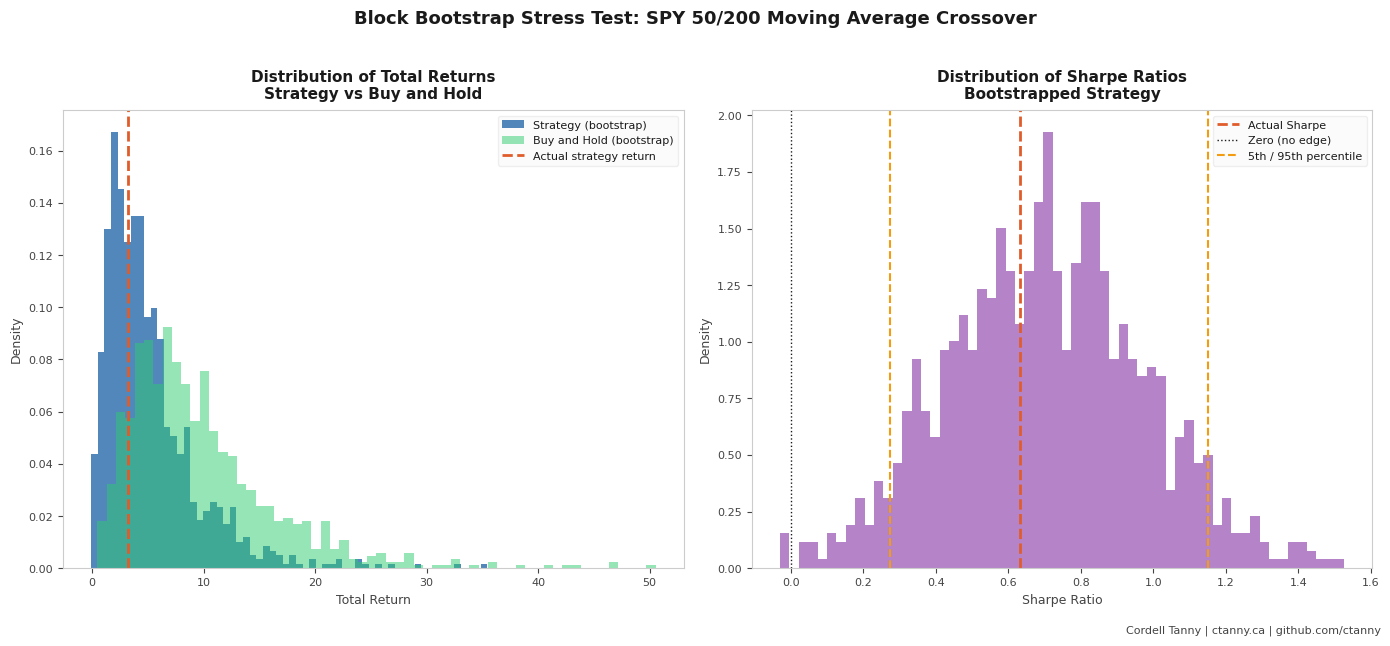

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

# Left: distribution of bootstrapped total returns
axes[0].hist(boot_total_returns, bins=60, density=True,
             color='#185FA5', alpha=0.75, label='Strategy (bootstrap)')
axes[0].hist(bh_total_returns,   bins=60, density=True,
             color='#2ECC71', alpha=0.5,  label='Buy and Hold (bootstrap)')
axes[0].axvline(total_return(actual_strat), color='#E05C2A',
                linewidth=2, linestyle='--', label='Actual strategy return')
axes[0].set_title('Distribution of Total Returns\nStrategy vs Buy and Hold',
                  color='#1a1a1a', fontsize=11, fontweight='bold', pad=8)
axes[0].set_xlabel('Total Return', color='#444444', fontsize=9)
axes[0].set_ylabel('Density',      color='#444444', fontsize=9)
axes[0].tick_params(colors='#444444', labelsize=8)
for sp in axes[0].spines.values():
    sp.set_edgecolor('#cccccc')
axes[0].legend(fontsize=8, framealpha=0.3, labelcolor='#1a1a1a',
               facecolor='#f5f5f5', edgecolor='#cccccc')

# Right: distribution of bootstrapped Sharpe ratios
axes[1].hist(boot_sharpes, bins=60, density=True,
             color='#9B59B6', alpha=0.75)
axes[1].axvline(sharpe_ratio(actual_strat), color='#E05C2A',
                linewidth=2, linestyle='--', label='Actual Sharpe')
axes[1].axvline(0, color='#1a1a1a', linewidth=1, linestyle=':',
                label='Zero (no edge)')
axes[1].axvline(np.percentile(boot_sharpes, 5),  color='#F39C12',
                linewidth=1.5, linestyle='--', label='5th / 95th percentile')
axes[1].axvline(np.percentile(boot_sharpes, 95), color='#F39C12',
                linewidth=1.5, linestyle='--')
axes[1].set_title('Distribution of Sharpe Ratios\nBootstrapped Strategy',
                  color='#1a1a1a', fontsize=11, fontweight='bold', pad=8)
axes[1].set_xlabel('Sharpe Ratio', color='#444444', fontsize=9)
axes[1].set_ylabel('Density',      color='#444444', fontsize=9)
axes[1].tick_params(colors='#444444', labelsize=8)
for sp in axes[1].spines.values():
    sp.set_edgecolor('#cccccc')
axes[1].legend(fontsize=8, framealpha=0.3, labelcolor='#1a1a1a',
               facecolor='#f5f5f5', edgecolor='#cccccc')

fig.suptitle('Block Bootstrap Stress Test: SPY 50/200 Moving Average Crossover',
             color='#1a1a1a', fontsize=13, fontweight='bold', y=1.02)
plt.figtext(0.99, -0.02,
            'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('strategy_stress_test.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

## 9. Interpreting the Results

*Run the cells above and paste your output here. An interpretation cell will be added based on your actual results.*

Things to look for:
- Does the autocorrelation chart show clear volatility clustering in actual SPY returns that disappears after independent resampling?
- Which block length best preserves the fat tail behavior of the original distribution?
- Does independent resampling destroy the cross-asset correlations? How close does block bootstrap get to the actual correlation matrix?
- What percentage of bootstrap simulations does the strategy beat buy and hold?
- Where does the actual strategy Sharpe ratio sit relative to the bootstrap distribution? Is it in the middle, the top quartile, or an outlier?

## 10. Key Takeaways

1. **Independent resampling destroys structure.** Shuffling returns randomly preserves the marginal distribution but eliminates volatility clustering, momentum, and cross-asset correlations. These are not minor details. They are features of financial markets that your strategy has to live with.

2. **Block bootstrapping is a practical solution.** By resampling consecutive blocks of returns, you preserve the within-block structure while still generating a large number of alternative histories. It is not perfect, but it is a significant improvement over naive resampling.

3. **Block length is a meaningful choice.** Shorter blocks preserve local structure but may miss longer regime dynamics. Longer blocks capture more structure but give you fewer unique sequences to draw from. There is no universally correct answer. Match the block length to the time scale your strategy operates on.

4. **A single backtest is one draw from a distribution of possible outcomes.** Block bootstrapping shows you the full distribution. A strategy that looks strong on the actual history but sits in the tail of the bootstrap distribution is a strategy that got lucky. A strategy that looks strong across the full bootstrap distribution has a more credible edge.

5. **Apply the same block indices across all assets.** This is the critical detail for portfolio-level analysis. Using the same block selection for every asset preserves the cross-asset correlation structure that matters most during market stress.

---

**What comes next:**  
Now that we have a rigorous way to simulate return paths, the next step is to use these tools inside a proper Monte Carlo framework for portfolio analysis.

---

*Cordell Tanny, CFA, FRM, FDP*  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny](https://github.com/ctanny/quant-finance-snippets)  
*Questions or ideas? Connect on LinkedIn.*